In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Load the cleaned data
df = pd.read_csv('noshow_cleaned.csv')

# Separate features (X) and target (y)
X = df.drop(columns=['no_show'])
y = df['no_show']

# Split: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print("\nFeatures used:", X.columns.tolist())

Training rows: 57567
Testing rows: 14392

Features used: ['Age', 'Scholarship', 'hypertension', 'Diabetes', 'Alcoholism', 'handicap', 'sms_received', 'waiting_days', 'gender_encoded', 'appt_dayofweek']


In [2]:
# Train Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,  # 100 decision trees
    random_state=42,
    n_jobs=-1          # use all CPU cores for speed
)

print("Training model... please wait")
rf_model.fit(X_train, y_train)
print("Done!")

# Test the model
y_pred = rf_model.predict(X_test)

# Results
print("\nAccuracy:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred, target_names=['Showed up', 'No-show']))

Training model... please wait
Done!

Accuracy: 65.84 %

Detailed Report:
              precision    recall  f1-score   support

   Showed up       0.73      0.83      0.78     10301
     No-show       0.35      0.24      0.28      4091

    accuracy                           0.66     14392
   macro avg       0.54      0.53      0.53     14392
weighted avg       0.62      0.66      0.64     14392



In [3]:
# Fix imbalance using class_weight='balanced'
rf_model2 = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',  # this fixes the imbalance!
    n_jobs=-1
)

print("Training improved model...")
rf_model2.fit(X_train, y_train)
print("Done!")

y_pred2 = rf_model2.predict(X_test)

print("\nImproved Accuracy:", round(accuracy_score(y_test, y_pred2) * 100, 2), "%")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred2, target_names=['Showed up', 'No-show']))

Training improved model...
Done!

Improved Accuracy: 62.76 %

Detailed Report:
              precision    recall  f1-score   support

   Showed up       0.73      0.76      0.74     10301
     No-show       0.33      0.30      0.31      4091

    accuracy                           0.63     14392
   macro avg       0.53      0.53      0.53     14392
weighted avg       0.62      0.63      0.62     14392



In [4]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred2)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Showed up', 'No-show'],
            yticklabels=['Showed up', 'No-show'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

print(f"\nCorrectly caught no-shows: {cm[1][1]}")
print(f"Missed no-shows: {cm[1][0]}")

NameError: name 'sns' is not defined

<Figure size 800x600 with 0 Axes>

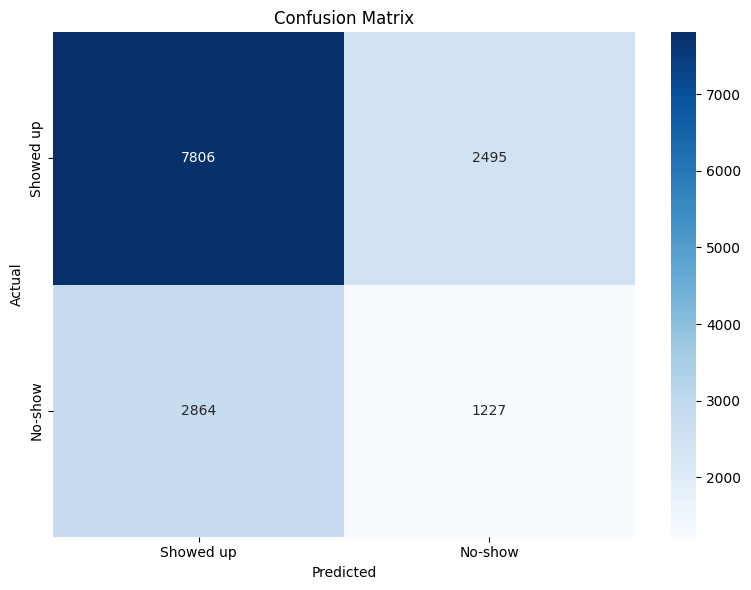


Correctly caught no-shows: 1227
Missed no-shows: 2864


In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion matrix
cm = confusion_matrix(y_test, y_pred2)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Showed up', 'No-show'],
            yticklabels=['Showed up', 'No-show'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

print(f"\nCorrectly caught no-shows: {cm[1][1]}")
print(f"Missed no-shows: {cm[1][0]}")

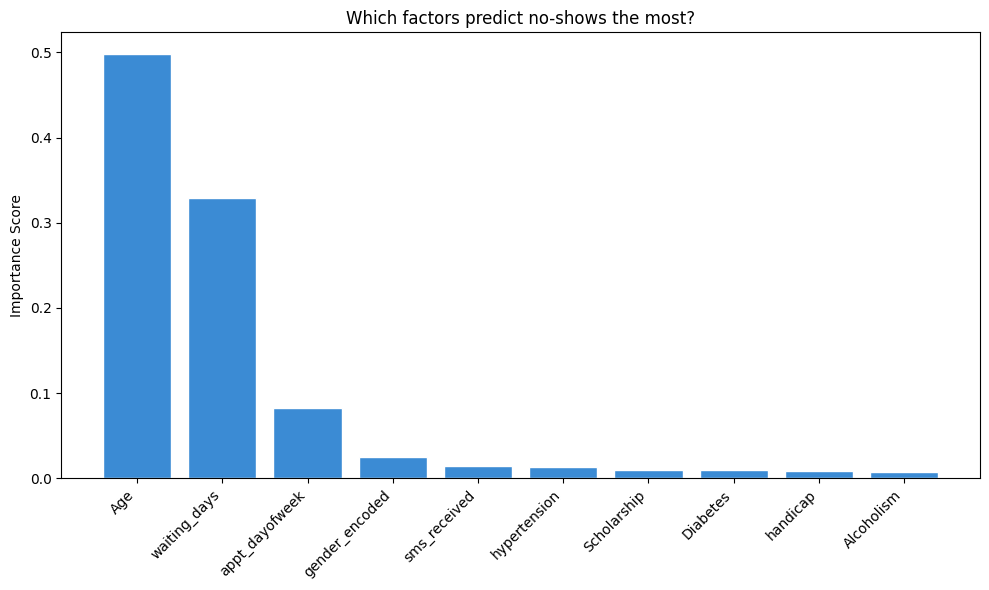


Feature Ranking:
1. Age: 0.4987
2. waiting_days: 0.3291
3. appt_dayofweek: 0.0828
4. gender_encoded: 0.0254
5. sms_received: 0.0150
6. hypertension: 0.0131
7. Scholarship: 0.0101
8. Diabetes: 0.0099
9. handicap: 0.0091
10. Alcoholism: 0.0069


In [6]:
# Get feature importances
feature_names = X.columns.tolist()
importances = rf_model2.feature_importances_

# Sort them
indices = np.argsort(importances)[::-1]

# Plot
plt.figure(figsize=(10, 6))
plt.bar(range(len(importances)), 
        importances[indices], 
        color='#3B8BD4', edgecolor='white')
plt.xticks(range(len(importances)), 
           [feature_names[i] for i in indices], 
           rotation=45, ha='right')
plt.title('Which factors predict no-shows the most?')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

# Print ranking
print("\nFeature Ranking:")
for i, idx in enumerate(indices):
    print(f"{i+1}. {feature_names[idx]}: {importances[idx]:.4f}")

In [7]:
import pickle

# Save model to file
with open('noshow_model.pkl', 'wb') as f:
    pickle.dump(rf_model2, f)

# Save feature names too
with open('feature_names.pkl', 'wb') as f:
    pickle.dump(feature_names, f)

print("Model saved successfully!")
print("Files created: noshow_model.pkl, feature_names.pkl")

Model saved successfully!
Files created: noshow_model.pkl, feature_names.pkl
